In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install kmodes

In [3]:
import numpy as np
import pandas as pd
from sklearn import metrics, preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from kmodes.kmodes import KModes
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
file_path = '/content/drive/My Drive/heart dataset 3.csv'
df = pd.read_csv(file_path, sep=',', encoding='utf-8')
df.head()

,Sex,GeneralHealth,Blood pressure,SleepHours,HadAngina,HadAsthma,HadCOPD,HadDepressiveDisorder,HadDiabetes,SmokerStatus,ECigaretteUsage,BMI,AgeCategory,target
0,Female,Very good,Yes,7.0,No,No,No,Yes,No,Never smoked,Never used e-cigarettes in my entire life,40.89,Age 55 to 59,yes
1,Male,Very good,No,9.0,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,31.47,Age 60 to 64,yes
2,Female,Very good,Yes,7.0,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,28.89,Age 30 to 34,No
3,Female,Very good,Yes,7.0,No,No,No,No,No,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,24.96,Age 18 to 24,No
4,Male,Very good,Yes,6.0,No,No,No,No,No,Current smoker - now smokes every day,Never used e-cigarettes in my entire life,29.05,Age 30 to 34,No


In [ ]:
class_counts = df['target'].value_counts()
class_percent = df['target'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent.round(2)
}))

gender_counts = df['Sex'].value_counts()
gender_percent = df['Sex'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    "Count": gender_counts,
    "Percentage": gender_percent.round(2)
}))

print("Mean BMI:", round(df['BMI'].mean(), 2))
print("SD BMI:", round(df['BMI'].std(), 2))

print("Mean SleepHours:", round(df['SleepHours'].mean(), 2))
print("SD SleepHours:", round(df['SleepHours'].std(), 2))

import pandas as pd

ignore_cols = ["SleepHours", "AgeCategory", "BMI", "Sex", "target"]

cols_to_summarize = [
    "GeneralHealth", "Blood pressure", "HadAngina", "HadAsthma",
    "HadCOPD", "HadDepressiveDisorder", "HadDiabetes",
    "SmokerStatus", "ECigaretteUsage"
]

def print_counts_percent(series):
    counts = series.value_counts(dropna=False)
    perc = series.value_counts(normalize=True, dropna=False) * 100
    table = pd.DataFrame({"Count": counts, "Percent": perc.round(2)})
    print(table)
    print()
    return table

print("===== DEMOGRAPHIC SUMMARY (Filtered Variables) =====\n")

for col in cols_to_summarize:
    if col in df.columns:
        print(f"--- {col} ---")
        print_counts_percent(df[col])


        Count  Percentage
target                   
yes     90768       60.51
No      59232       39.49
        Count  Percentage
Sex                      
Female  76470       50.98
Male    73527       49.02
Mean BMI: 28.05
SD BMI: 6.3
Mean SleepHours: 7.02
SD SleepHours: 1.45
===== DEMOGRAPHIC SUMMARY (Filtered Variables) =====

--- GeneralHealth ---
               Count  Percent
GeneralHealth                
Very good      53010    35.34
Good           46806    31.20
Excellent      26085    17.39
Fair           18479    12.32
Poor            5616     3.74
NaN                4     0.00

--- Blood pressure ---
                 Count  Percent
Blood pressure                 
Yes             117100    78.07
No               32898    21.93
NaN                  2     0.00

--- HadAngina ---
            Count  Percent
HadAngina                 
No         142395    94.93
Yes          7602     5.07
NaN             3     0.00

--- HadAsthma ---
            Count  Percent
HadAsthma             

# **Drop duplicate values**

In [ ]:
# View structure if needed
print(df.shape)

# Check for full row duplicates (before preprocessing)
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows (before preprocessing): {duplicates_count}")

df = df.drop_duplicates().reset_index(drop=True)

# Train test split

In [6]:
# Separate features and target
X = df.drop(columns=['target'])
y = df['target'].str.lower().map({'yes': 1, 'no': 0})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Total samples:", len(df))
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Total samples: 139019
Training samples: 111215
Testing samples: 27804


In [ ]:
print("Train class counts:")
print(y_train.value_counts())

print("\nTest class counts:")
print(y_test.value_counts())


Train class counts:
target
1    68561
0    42654
Name: count, dtype: int64

Test class counts:
target
1    17140
0    10664
Name: count, dtype: int64


In [ ]:
# Check column data types
X_train.dtypes


,0
Sex,object
GeneralHealth,object
Blood pressure,object
SleepHours,float64
HadAngina,object
HadAsthma,object
HadCOPD,object
HadDepressiveDisorder,object
HadDiabetes,object
SmokerStatus,object


# **Encoding**

In [8]:
# Mapping for Sex column
sex_map = {
    'Female': 0,
    'Male': 1
}

# Apply mapping
X_train['Sex'] = X_train['Sex'].map(sex_map)
X_test['Sex'] = X_test['Sex'].map(sex_map)


In [10]:
print(X_train['Sex'].value_counts())
print(X_test['Sex'].value_counts())


Sex
0.0    56669
1.0    54544
Name: count, dtype: int64
Sex
0.0    14282
1.0    13521
Name: count, dtype: int64


In [9]:
binary_map = {
    'Yes': 1, 'No': 0,
    'yes': 1, 'no': 0,
}

binary_cols = [
    'Blood pressure', 'HadAngina', 'HadAsthma',
    'HadCOPD', 'HadDepressiveDisorder', 'HadDiabetes'
]

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_test[col] = X_test[col].map(binary_map)


In [10]:
# Ordinal mapping for GeneralHealth
general_health_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Very good': 3,
    'Excellent': 4
}

# Apply mapping
X_train['GeneralHealth'] = X_train['GeneralHealth'].map(general_health_map)
X_test['GeneralHealth'] = X_test['GeneralHealth'].map(general_health_map)


In [ ]:
print(X_train['GeneralHealth'].value_counts().sort_index())
print(X_test['GeneralHealth'].value_counts().sort_index())


GeneralHealth
0.0     4479
1.0    14687
2.0    36019
3.0    37539
4.0    18488
Name: count, dtype: int64
GeneralHealth
0.0    1137
1.0    3724
2.0    8921
3.0    9390
4.0    4631
Name: count, dtype: int64


In [11]:
# Ordinal mapping for AgeCategory
age_map = {
    'Age 18 to 24': 0,
    'Age 25 to 29': 1,
    'Age 30 to 34': 2,
    'Age 35 to 39': 3,
    'Age 40 to 44': 4,
    'Age 45 to 49': 5,
    'Age 50 to 54': 6,
    'Age 55 to 59': 7,
    'Age 60 to 64': 8,
    'Age 65 to 69': 9,
    'Age 70 to 74': 10,
    'Age 75 to 79': 11,
    'Age 80 or older': 12
}

# Apply mapping
X_train['AgeCategory'] = X_train['AgeCategory'].map(age_map)
X_test['AgeCategory'] = X_test['AgeCategory'].map(age_map)


In [ ]:
print(X_train['AgeCategory'].value_counts().sort_index())
print(X_test['AgeCategory'].value_counts().sort_index())


AgeCategory
0.0      8053
1.0      6567
2.0      7624
3.0      8466
4.0      8862
5.0      8445
6.0      9954
7.0      8135
8.0      9843
9.0     10250
10.0     9685
11.0     7301
12.0     8029
Name: count, dtype: int64
AgeCategory
0.0     1968
1.0     1725
2.0     1996
3.0     2074
4.0     2168
5.0     2047
6.0     2428
7.0     2037
8.0     2434
9.0     2669
10.0    2351
11.0    1798
12.0    2107
Name: count, dtype: int64


In [12]:
# Ordinal mapping for SmokerStatus
smoker_map = {
    'Never smoked': 0,
    'Former smoker': 1,
    'Current smoker - now smokes some days': 2,
    'Current smoker - now smokes every day': 3
}

# Apply mapping
X_train['SmokerStatus'] = X_train['SmokerStatus'].map(smoker_map)
X_test['SmokerStatus'] = X_test['SmokerStatus'].map(smoker_map)

print(X_train['SmokerStatus'].value_counts().sort_index())
print(X_test['SmokerStatus'].value_counts().sort_index())


SmokerStatus
0.0    64935
1.0    31793
2.0     4099
3.0    10386
Name: count, dtype: int64
SmokerStatus
0.0    16161
1.0     7963
2.0     1072
3.0     2606
Name: count, dtype: int64


In [13]:
# Ordinal mapping for ECigaretteUsage (final)
ecig_map = {
    'Never used e-cigarettes in my entire life': 0,
    'Not at all (right now)': 1,
    'Use them some days': 2,
    'Use them every day': 3
}

# Apply mapping
X_train['ECigaretteUsage'] = X_train['ECigaretteUsage'].map(ecig_map)
X_test['ECigaretteUsage'] = X_test['ECigaretteUsage'].map(ecig_map)


print(X_train['ECigaretteUsage'].value_counts().sort_index())
print(X_test['ECigaretteUsage'].value_counts().sort_index())


ECigaretteUsage
0.0    82767
1.0    21705
2.0     3572
3.0     3166
Name: count, dtype: int64
ECigaretteUsage
0.0    20523
1.0     5484
2.0      967
3.0      829
Name: count, dtype: int64


In [14]:
# SleepHours binning
sleep_bins = [0, 5, 8, 12, 18, 24]
sleep_labels = ['low', 'normal', 'high', 'very high', 'Extreme']

X_train['SleepHours_binned'] = pd.cut(
    X_train['SleepHours'],
    bins=sleep_bins,
    labels=sleep_labels,
    include_lowest=True
)

X_test['SleepHours_binned'] = pd.cut(
    X_test['SleepHours'],
    bins=sleep_bins,
    labels=sleep_labels,
    include_lowest=True
)

# Encode SleepHours bins (IMPORTANT: astype(str))
sleep_map = {
    'low': 0,
    'normal': 1,
    'high': 2,
    'very high': 3,
    'Extreme': 4
}

X_train['SleepHours'] = X_train['SleepHours_binned'].astype(str).map(sleep_map)
X_test['SleepHours'] = X_test['SleepHours_binned'].astype(str).map(sleep_map)

# Drop temporary column
X_train.drop(columns=['SleepHours_binned'], inplace=True)
X_test.drop(columns=['SleepHours_binned'], inplace=True)


In [15]:
# BMI binning
bmi_bins = [0, 18.5, 24.9, 29.9, 100]
bmi_labels = ['underweight', 'normal', 'overweight', 'obese']

X_train['BMI_binned'] = pd.cut(
    X_train['BMI'],
    bins=bmi_bins,
    labels=bmi_labels,
    include_lowest=True
)

X_test['BMI_binned'] = pd.cut(
    X_test['BMI'],
    bins=bmi_bins,
    labels=bmi_labels,
    include_lowest=True
)

# Encode BMI bins
bmi_map = {
    'underweight': 0,
    'normal': 1,
    'overweight': 2,
    'obese': 3
}

X_train['BMI'] = X_train['BMI_binned'].astype(str).map(bmi_map)
X_test['BMI'] = X_test['BMI_binned'].astype(str).map(bmi_map)
# Drop temporary column
X_train.drop(columns=['BMI_binned'], inplace=True)
X_test.drop(columns=['BMI_binned'], inplace=True)


In [ ]:
X_train.dtypes


,0
Sex,float64
GeneralHealth,float64
Blood pressure,float64
SleepHours,float64
HadAngina,float64
HadAsthma,int64
HadCOPD,float64
HadDepressiveDisorder,float64
HadDiabetes,float64
SmokerStatus,float64


In [ ]:
X_train.head()


,Sex,GeneralHealth,Blood pressure,SleepHours,HadAngina,HadAsthma,HadCOPD,HadDepressiveDisorder,HadDiabetes,SmokerStatus,ECigaretteUsage,BMI,AgeCategory
49117,0.0,2.0,1.0,1.0,0.0,0,0.0,1.0,1.0,3.0,0.0,2,10.0
54748,1.0,4.0,1.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,1.0
2290,1.0,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,2,10.0
97266,0.0,2.0,1.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,3,3.0
4814,0.0,3.0,0.0,2.0,0.0,0,1.0,0.0,0.0,3.0,1.0,2,2.0


# Missing values

In [16]:
X_train.isna().sum()



,0
Sex,2
GeneralHealth,3
Blood pressure,1
SleepHours,2
HadAngina,1
HadAsthma,0
HadCOPD,2
HadDepressiveDisorder,3
HadDiabetes,3558
SmokerStatus,2


In [17]:
X_test.isna().sum()

,0
Sex,1
GeneralHealth,1
Blood pressure,1
SleepHours,1
HadAngina,2
HadAsthma,3
HadCOPD,1
HadDepressiveDisorder,0
HadDiabetes,889
SmokerStatus,2


In [18]:
y_train.isna().sum()
y_test.isna().sum()


np.int64(0)

In [19]:
# Find rows without missing values
train_mask = X_train.notna().all(axis=1)

# Apply mask to X and y
X_train = X_train[train_mask]
y_train = y_train[train_mask]


In [20]:
test_mask = X_test.notna().all(axis=1)

X_test = X_test[test_mask]
y_test = y_test[test_mask]


In [21]:
X_train.isna().sum()
X_test.isna().sum()


,0
Sex,0
GeneralHealth,0
Blood pressure,0
SleepHours,0
HadAngina,0
HadAsthma,0
HadCOPD,0
HadDepressiveDisorder,0
HadDiabetes,0
SmokerStatus,0


In [ ]:
print("Train size after cleaning:", X_train.shape[0])
print("Test size after cleaning:", X_test.shape[0])


Train size after cleaning: 107639
Test size after cleaning: 26911


In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


target
1    0.614145
0    0.385855
Name: proportion, dtype: float64
target
1    0.614173
0    0.385827
Name: proportion, dtype: float64


**Clustering**

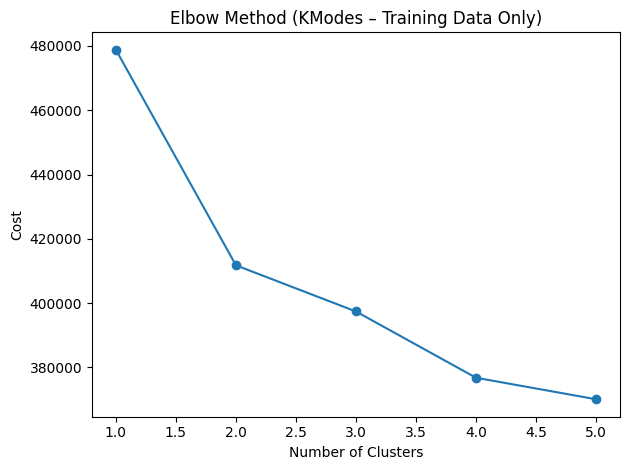

In [22]:
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

# Use ALL features (already discrete)
X_train_km = X_train.copy()
X_test_km  = X_test.copy()

cost = []
num_clusters = range(1, 6)

for k in num_clusters:
    km = KModes(
        n_clusters=k,
        init='Huang',
        n_init=5,
        verbose=0,
        random_state=42
    )
    km.fit(X_train_km)
    cost.append(km.cost_)

plt.plot(num_clusters, cost, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Cost')
plt.title('Elbow Method (KModes – Training Data Only)')
plt.tight_layout()
plt.show()


In [23]:
# Choose number of clusters (example: k = 2)
k = 2

km = KModes(
    n_clusters=k,
    init='Huang',
    n_init=5,
    random_state=42
)

# Fit ONLY on training data
train_clusters = km.fit_predict(X_train_km)

# Predict clusters for test data
test_clusters = km.predict(X_test_km)



In [24]:
X_train['Cluster'] = train_clusters
X_test['Cluster']  = test_clusters


In [ ]:
print("Train cluster distribution:")
print(pd.Series(train_clusters).value_counts())

print("\nTest cluster distribution:")
print(pd.Series(test_clusters).value_counts())


Train cluster distribution:
0    66354
1    41285
Name: count, dtype: int64

Test cluster distribution:
0    16519
1    10392
Name: count, dtype: int64


In [ ]:
X_train.head()



,Sex,GeneralHealth,Blood pressure,SleepHours,HadAngina,HadAsthma,HadCOPD,HadDepressiveDisorder,HadDiabetes,SmokerStatus,ECigaretteUsage,BMI,AgeCategory,Cluster
49117,0.0,2.0,1.0,1.0,0.0,0,0.0,1.0,1.0,3.0,0.0,2,10.0,1
54748,1.0,4.0,1.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,1.0,0
2290,1.0,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,2,10.0,0
97266,0.0,2.0,1.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,3,3.0,1
4814,0.0,3.0,0.0,2.0,0.0,0,1.0,0.0,0.0,3.0,1.0,2,2.0,0


In [ ]:
print(X_train.shape)
print(X_test.shape)


(107639, 14)
(26911, 14)


In [ ]:
print("X_train_final rows:", X_train.shape[0])
print("y_train rows:", y_train.shape[0])

print("X_test_final rows:", X_test.shape[0])
print("y_test rows:", y_test.shape[0])


X_train_final rows: 107639
y_train rows: 107639
X_test_final rows: 26911
y_test rows: 26911


# **Model implementation**

# **Stacking Model**

In [26]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

base_models = [
    ('Random_Forest', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('ExtraTrees', ExtraTreesClassifier(
        n_estimators=550,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('DecisionTree', DecisionTreeClassifier(
        max_depth=7,
        random_state=42
    ))
]

lr_model = LogisticRegression(
    C=100,
    max_iter=1000,
    penalty='l2',
    solver='liblinear',
    random_state=42
)

stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=lr_model,
    cv=5,
    stack_method='predict_proba'
)


# Train
stacking_classifier.fit(X_train, y_train)

# Predict
y_train_pred = stacking_classifier.predict(X_train)
y_test_pred = stacking_classifier.predict(X_test)

# Evaluate
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.6f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.6f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 0.995829
Test Accuracy: 0.995169

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10383
           1       0.99      1.00      1.00     16528

    accuracy                           1.00     26911
   macro avg       1.00      0.99      0.99     26911
weighted avg       1.00      1.00      1.00     26911



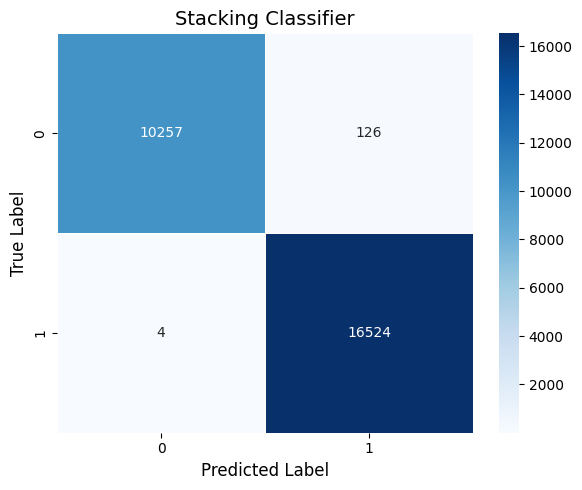

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, model_name,
                          labels=['0', '1'],
                          figsize=(6, 5),
                          cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5
    )

    plt.title(f'{model_name}', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()


# Use the CORRECT prediction variable
plot_confusion_matrix(
    y_test,
    y_test_pred,        # <-- this is the key fix
    'Stacking Classifier',
    labels=['0', '1']
)


Stacking classifier with 0, 7, 123 and 2024 seed value

In [28]:
import pandas as pd
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Seeds for model randomness
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    # ================================
    # Base models (seed applied consistently)
    # ================================
    base_models = [
        ('Random_Forest', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=seed,
            n_jobs=-1
        )),
        ('ExtraTrees', ExtraTreesClassifier(
            n_estimators=550,
            max_depth=None,
            random_state=seed,
            n_jobs=-1
        )),
        ('DecisionTree', DecisionTreeClassifier(
            max_depth=7,
            random_state=seed
        ))
    ]

    # Meta-learner
    lr_model = LogisticRegression(
        C=100,
        max_iter=1000,
        penalty='l2',
        solver='liblinear',
        random_state=seed
    )

    # Stacking classifier (internal CV on TRAINING data only)
    stacking_classifier = StackingClassifier(
        estimators=base_models,
        final_estimator=lr_model,
        cv=5,
        n_jobs=-1
    )

    # ================================
    # Train on FIXED training set
    # ================================
    stacking_classifier.fit(X_train, y_train)

    # ================================
    # Evaluate on FIXED test set
    # ================================
    y_pred = stacking_classifier.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

# ================================
# Results table
# ================================
df_stack = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print(df_stack)

print("\nSummary Statistics:")
print(df_stack.describe())


   Seed      Accuracy     Precision        Recall            F1
0     0  0.9951692616  0.9924324324  0.9997579864  0.9960817409
1     7  0.9951692616  0.9924324324  0.9997579864  0.9960817409
2   123  0.9951692616  0.9924324324  0.9997579864  0.9960817409
3  2024  0.9951692616  0.9924324324  0.9997579864  0.9960817409

Summary Statistics:
                  Seed      Accuracy     Precision        Recall            F1
count     4.0000000000  4.0000000000  4.0000000000  4.0000000000  4.0000000000
mean    538.5000000000  0.9951692616  0.9924324324  0.9997579864  0.9960817409
std     991.9383381373  0.0000000000  0.0000000000  0.0000000000  0.0000000000
min       0.0000000000  0.9951692616  0.9924324324  0.9997579864  0.9960817409
25%       5.2500000000  0.9951692616  0.9924324324  0.9997579864  0.9960817409
50%      65.0000000000  0.9951692616  0.9924324324  0.9997579864  0.9960817409
75%     598.2500000000  0.9951692616  0.9924324324  0.9997579864  0.9960817409
max    2024.0000000000  0.9

# **Simple feedfoward neural network**

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score

# Build model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train (use existing training data)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # (comes only from TRAIN)
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predictions
y_train_pred = (model.predict(X_train) > 0.5).astype(int)
y_test_pred = (model.predict(X_test) > 0.5).astype(int)

# Evaluation
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.6f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.6f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))


Epoch 1/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9557 - loss: 0.1073 - val_accuracy: 0.9957 - val_loss: 0.0258
Epoch 2/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9948 - loss: 0.0229 - val_accuracy: 0.9960 - val_loss: 0.0182
Epoch 3/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9935 - loss: 0.0272 - val_accuracy: 0.9960 - val_loss: 0.0193
Epoch 4/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9944 - loss: 0.0238 - val_accuracy: 0.9960 - val_loss: 0.0214
Epoch 5/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9955 - loss: 0.0210 - val_accuracy: 0.9960 - val_loss: 0.0182
Epoch 6/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9953 - loss: 0.0212 - val_accuracy: 0.9960 - val_loss: 0.0183
Epoch 7/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9947 - loss: 0.0227 - val_accuracy: 0.9960 - val_loss: 0.0181
Epoch 8/20
2691/2691 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9948 - loss: 0.0230 -

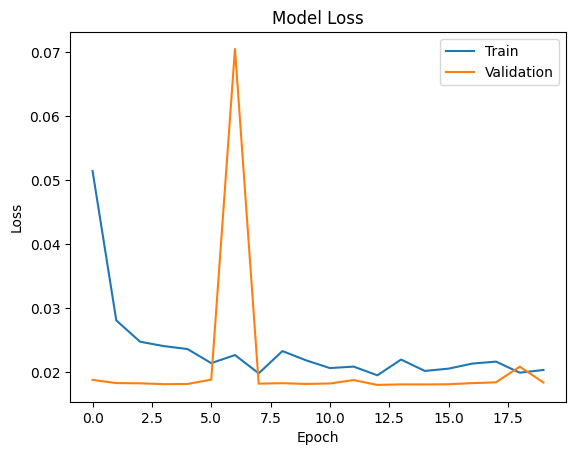

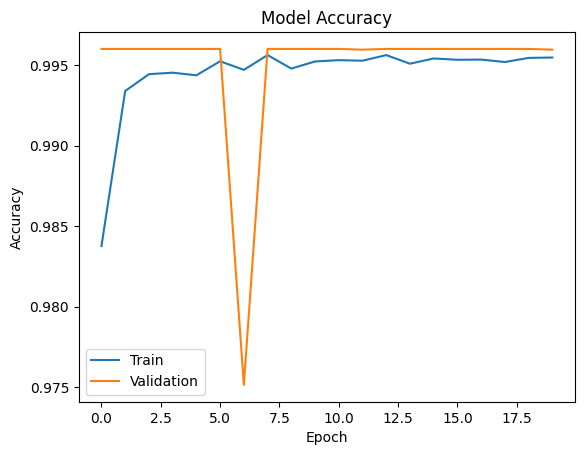

In [ ]:
# ================================
# Plot Loss and Accuracy
# ================================
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

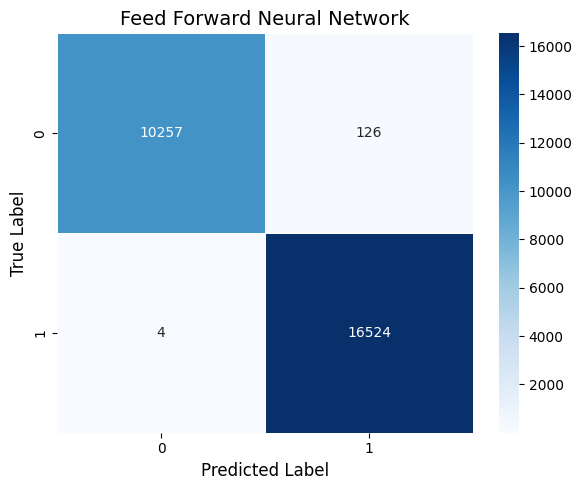

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, model_name,
                          labels=['0', '1'],
                          figsize=(6, 5),
                          cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5
    )

    plt.title(f'{model_name}', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()


# Confusion matrix for FFNN
plot_confusion_matrix(
    y_test,
    y_test_pred,          # <-- FFNN predictions
    'Feed Forward Neural Network',
    labels=['0', '1']
)


Simple feedforward neural network with 0, 7, 123 and 2024 seed value

In [29]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Seeds for model randomness (NOT data splitting)
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    # ================================
    # Reproducibility
    # ================================
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # ================================
    # Build model
    # ================================
    model = Sequential()
    model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # ================================
    # Train on FIXED training set
    # ================================
    model.fit(
        X_train, y_train,
        validation_split=0.2,   # comes only from TRAIN
        epochs=20,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # ================================
    # Evaluate on FIXED test set
    # ================================
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

# ================================
# Results table
# ================================
df_ffnn = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print(df_ffnn)

print("\nSummary Statistics:")
print(df_ffnn.describe())


841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
   Seed      Accuracy   Precision  Recall            F1
0     0  0.9953178997  0.99243425     1.0  0.9962027605
1     7  0.9953178997  0.99243425     1.0  0.9962027605
2   123  0.9953178997  0.99243425     1.0  0.9962027605
3  2024  0.9953178997  0.99243425     1.0  0.9962027605

Summary Statistics:
                  Seed      Accuracy   Precision  Recall            F1
count     4.0000000000  4.0000000000  4.00000000     4.0  4.0000000000
mean    538.5000000000  0.9953178997  0.99243425     1.0  0.9962027605
std     991.9383381373  0.0000000000  0.00000000     0.0  0.0000000000
min       0.0000000000  0.9953178997  0.99243425     1.0  0.9962027605
25%       5.2500000000  0.9953178997  0.99243425     1.0  0.9962027605
50%      65.0000000000  0.9953178997  0.99243425     1.0  0.9962027605
75%     598.2500000000  0.9953178997  

# **CNN**

Epoch 1/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.9684 - loss: 0.0804 - val_accuracy: 0.9943 - val_loss: 0.0322
Epoch 2/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9931 - loss: 0.0268 - val_accuracy: 0.9953 - val_loss: 0.0209
Epoch 3/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9921 - loss: 0.0296 - val_accuracy: 0.9953 - val_loss: 0.0208
Epoch 4/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9944 - loss: 0.0231 - val_accuracy: 0.9953 - val_loss: 0.0202
Epoch 5/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9943 - loss: 0.0233 - val_accuracy: 0.9952 - val_loss: 0.0207
Epoch 6/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9952 - loss: 0.0214 - val_accuracy: 0.9953 - val_loss: 0.0202
Epoch 7/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9954 - loss: 0.0209 - val_accuracy: 0.9953 - val_loss: 0.0201
Epoch 8/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9945 - loss: 0.0230 - 

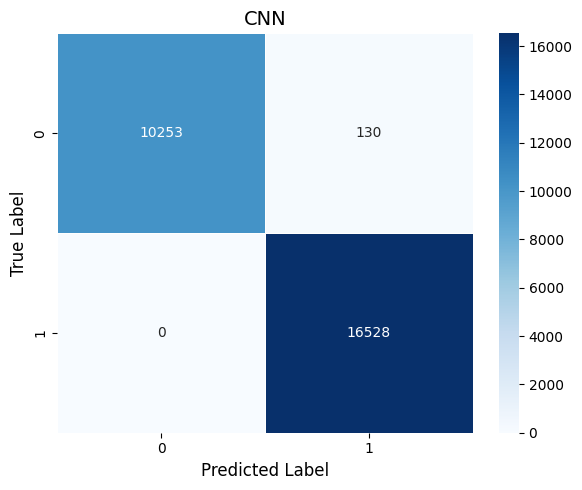

In [29]:
# ======================================================
# 1D Convolutional Neural Network (CNN) – FINAL VERSION
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


# ======================================================
# 1. Prepare data for CNN
# ======================================================

X_train_cnn = X_train.astype(float).values
X_test_cnn  = X_test.astype(float).values

# Reshape for Conv1D
# Shape: (samples, features, channels)
X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
X_test_cnn  = X_test_cnn.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)


# ======================================================
# 2. Build CNN model (binary classification)
# ======================================================

model_cnn = Sequential([

    Conv1D(
        filters=64,
        kernel_size=2,
        padding='same',
        activation='relu',
        input_shape=(X_train_cnn.shape[1], 1)
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=2,
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=256,
        kernel_size=2,
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')   # Binary output
])


# ======================================================
# 3. Compile CNN
# ======================================================

optimizer = Adam(learning_rate=0.001)

model_cnn.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ======================================================
# 4. Train CNN (NO leakage – fixed split)
# ======================================================

history = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=32,
    batch_size=128,
    validation_data=(X_test_cnn, y_test),
    verbose=1
)


# ======================================================
# 5. Predictions
# ======================================================

y_train_pred_cnn = (model_cnn.predict(X_train_cnn) > 0.5).astype(int).ravel()
y_test_pred_cnn  = (model_cnn.predict(X_test_cnn) > 0.5).astype(int).ravel()


# ======================================================
# 6. Accuracy
# ======================================================

cnn_train_acc = accuracy_score(y_train, y_train_pred_cnn)
cnn_test_acc  = accuracy_score(y_test, y_test_pred_cnn)

print(f"\n✅ CNN Training Accuracy:   {cnn_train_acc:.6f}")
print(f"✅ CNN Test Accuracy:       {cnn_test_acc:.6f}")


# ======================================================
# 7. Classification Report
# ======================================================

print("\n📌 CNN Classification Report:")
print(classification_report(y_test, y_test_pred_cnn))


# ======================================================
# 8. Confusion Matrix (same style as others)
# ======================================================

cm = confusion_matrix(y_test, y_test_pred_cnn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    linewidths=0.5
)

plt.title("CNN", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()


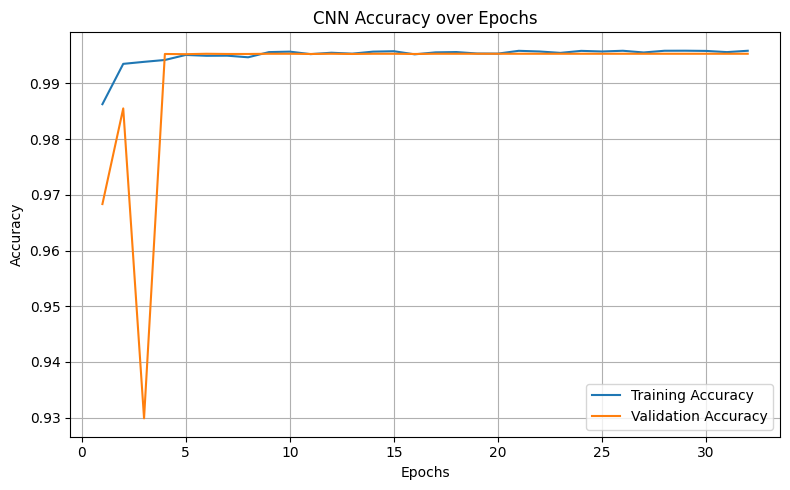

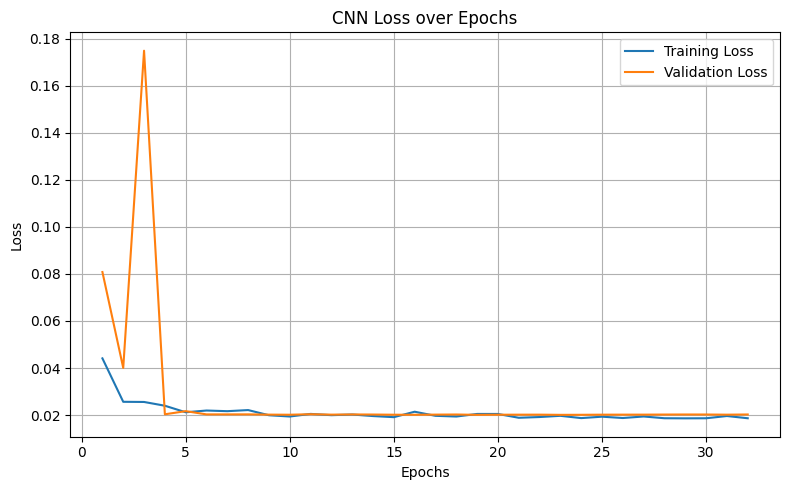

In [43]:
# ======================================================
# 9. Accuracy and Loss Curves
# ======================================================

# Extract history
train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss   = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

# -------- Accuracy Plot --------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------- Loss Plot --------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


CNN with seed value 0, 7, 123 and 2024

In [44]:
# ======================================================
# 1D Convolutional Neural Network (CNN)
# Seeds: 7, 123
# ======================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



# ======================================================
# Seeds for model randomness (NOT data splitting)
# ======================================================
seeds = [7, 123]

results = []

for seed in seeds:

    print("\n" + "="*50)
    print(f"🚀 Training CNN with Seed = {seed}")
    print("="*50)

    # ======================================================
    # Reproducibility
    # ======================================================
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # ======================================================
    # 1. Prepare data for CNN
    # ======================================================
    X_train_cnn = X_train.astype(float).values
    X_test_cnn  = X_test.astype(float).values

    # Reshape for Conv1D
    X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
    X_test_cnn  = X_test_cnn.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)

    # ======================================================
    # 2. Build CNN model (binary classification)
    # ======================================================
    model_cnn = Sequential([

        Conv1D(64, 2, padding='same', activation='relu',
               input_shape=(X_train_cnn.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(128, 2, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(256, 2, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.1),

        Dense(1, activation='sigmoid')
    ])

    # ======================================================
    # 3. Compile CNN
    # ======================================================
    model_cnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,              # stop after 5 bad epochs
    restore_best_weights=True,
    verbose=1
    )

    # ======================================================
    # 4. Train CNN
    # ======================================================
    model_cnn.fit(
        X_train_cnn, y_train,
        epochs=32,
        batch_size=128,
        validation_data=(X_test_cnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )

    # ======================================================
    # 5. Predictions
    # ======================================================
    y_test_pred_cnn = (model_cnn.predict(X_test_cnn) > 0.5).astype(int).ravel()

    # ======================================================
    # 6. Metrics
    # ======================================================
    acc  = accuracy_score(y_test, y_test_pred_cnn)
    prec = precision_score(y_test, y_test_pred_cnn, zero_division=0)
    rec  = recall_score(y_test, y_test_pred_cnn, zero_division=0)
    f1   = f1_score(y_test, y_test_pred_cnn, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\n✅ CNN Test Metrics (Seed {seed})")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ======================================================
# 8. Results table
# ======================================================
df_cnn = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\n📊 CNN Results Across Seeds")
print(df_cnn)

print("\n📈 Summary Statistics")
print(df_cnn.describe())



🚀 Training CNN with Seed = 7
Epoch 1/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.9759 - loss: 0.0660 - val_accuracy: 0.9953 - val_loss: 0.0215
Epoch 2/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9924 - loss: 0.0289 - val_accuracy: 0.9944 - val_loss: 0.0234
Epoch 3/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9943 - loss: 0.0245 - val_accuracy: 0.9948 - val_loss: 0.0221
Epoch 4/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9941 - loss: 0.0247 - val_accuracy: 0.9953 - val_loss: 0.0204
Epoch 5/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9944 - loss: 0.0237 - val_accuracy: 0.9953 - val_loss: 0.0203
Epoch 6/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.9945 - loss: 0.0234 - val_accuracy: 0.9953 - val_loss: 0.0204
Epoch 7/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9948 - loss: 0.0231 - val_accuracy: 0.9953 - val_loss: 0.0204
Epoch 8/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accu

In [45]:
# ======================================================
# 1D Convolutional Neural Network (CNN)
# Seeds: 7, 123
# ======================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



# ======================================================
# Seeds for model randomness (NOT data splitting)
# ======================================================
seeds = [0, 2024]

results = []

for seed in seeds:

    print("\n" + "="*50)
    print(f"🚀 Training CNN with Seed = {seed}")
    print("="*50)

    # ======================================================
    # Reproducibility
    # ======================================================
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # ======================================================
    # 1. Prepare data for CNN
    # ======================================================
    X_train_cnn = X_train.astype(float).values
    X_test_cnn  = X_test.astype(float).values

    # Reshape for Conv1D
    X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
    X_test_cnn  = X_test_cnn.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)

    # ======================================================
    # 2. Build CNN model (binary classification)
    # ======================================================
    model_cnn = Sequential([

        Conv1D(64, 2, padding='same', activation='relu',
               input_shape=(X_train_cnn.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(128, 2, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(256, 2, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.1),

        Dense(1, activation='sigmoid')
    ])

    # ======================================================
    # 3. Compile CNN
    # ======================================================
    model_cnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,              # stop after 5 bad epochs
    restore_best_weights=True,
    verbose=1
    )

    # ======================================================
    # 4. Train CNN
    # ======================================================
    model_cnn.fit(
        X_train_cnn, y_train,
        epochs=32,
        batch_size=128,
        validation_data=(X_test_cnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )

    # ======================================================
    # 5. Predictions
    # ======================================================
    y_test_pred_cnn = (model_cnn.predict(X_test_cnn) > 0.5).astype(int).ravel()

    # ======================================================
    # 6. Metrics
    # ======================================================
    acc  = accuracy_score(y_test, y_test_pred_cnn)
    prec = precision_score(y_test, y_test_pred_cnn, zero_division=0)
    rec  = recall_score(y_test, y_test_pred_cnn, zero_division=0)
    f1   = f1_score(y_test, y_test_pred_cnn, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\n✅ CNN Test Metrics (Seed {seed})")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ======================================================
# 8. Results table
# ======================================================
df_cnn = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\n📊 CNN Results Across Seeds")
print(df_cnn)

print("\n📈 Summary Statistics")
print(df_cnn.describe())



🚀 Training CNN with Seed = 0
Epoch 1/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.9797 - loss: 0.0608 - val_accuracy: 0.9951 - val_loss: 0.0221
Epoch 2/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9929 - loss: 0.0276 - val_accuracy: 0.9481 - val_loss: 0.1708
Epoch 3/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9932 - loss: 0.0266 - val_accuracy: 0.9487 - val_loss: 0.1703
Epoch 4/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9933 - loss: 0.0275 - val_accuracy: 0.9478 - val_loss: 0.2071
Epoch 5/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9937 - loss: 0.0263 - val_accuracy: 0.9847 - val_loss: 0.0446
Epoch 6/32
841/841 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9944 - loss: 0.0253 - val_accuracy: 0.9942 - val_loss: 0.0315
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
841/841 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

✅ CNN Test Metrics (Seed 0)
Accuracy : 0.995132
Precision: 0.9924

# **Decision Tree**

Training Accuracy: 0.996014
Test Accuracy: 0.994761

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10383
           1       0.99      1.00      1.00     16528

    accuracy                           0.99     26911
   macro avg       1.00      0.99      0.99     26911
weighted avg       0.99      0.99      0.99     26911



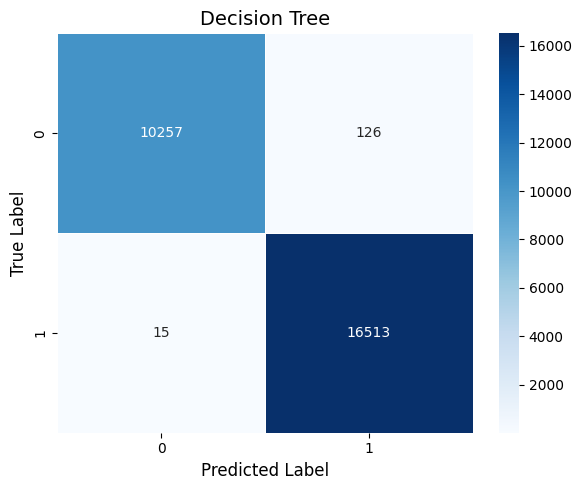

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 1. Initialize Decision Tree (same hyperparameters)
# ======================================================

dt_model = DecisionTreeClassifier(
    random_state=42,
    criterion="entropy",
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=10
)

# ======================================================
# 2. Train model (NO re-splitting)
# ======================================================

dt_model.fit(X_train, y_train)

# ======================================================
# 3. Predictions
# ======================================================

y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt  = dt_model.predict(X_test)

# ======================================================
# 4. Evaluation
# ======================================================

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_dt):.6f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_dt):.6f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_dt))

# ======================================================
# 5. Confusion Matrix
# ======================================================

conf_matrix = confusion_matrix(y_test, y_test_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    linewidths=0.5
)

plt.title('Decision Tree', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


Decision Tree with 0, 7, 123 and 2024 seed value

In [32]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ------------------------------------------------------
# Data already prepared (FIXED – no re-splitting)
# X_train, X_test
# y_train, y_test
# ------------------------------------------------------

seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training Decision Tree with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Set seed (model randomness only)
    # -----------------------------
    np.random.seed(seed)

    # -----------------------------
    # Decision Tree model (UNCHANGED)
    # -----------------------------
    dt_model = DecisionTreeClassifier(
        random_state=seed,
        criterion="entropy",
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=10
    )

    # -----------------------------
    # Train
    # -----------------------------
    dt_model.fit(X_train, y_train)

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_pred = dt_model.predict(X_test)

    # -----------------------------
    # Metrics (same as other models)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Test Metrics")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_dt = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\n📊 Decision Tree – Seed Stability Results")
print(df_dt)

print("\n📈 Summary Statistics")
print(df_dt.describe())



 Training Decision Tree with seed = 0

Seed 0 – Test Metrics
Accuracy : 0.994723
Precision: 0.992427
Recall   : 0.999032
F1-score : 0.995719

 Training Decision Tree with seed = 7

Seed 7 – Test Metrics
Accuracy : 0.994723
Precision: 0.992427
Recall   : 0.999032
F1-score : 0.995719

 Training Decision Tree with seed = 123

Seed 123 – Test Metrics
Accuracy : 0.994761
Precision: 0.992427
Recall   : 0.999092
F1-score : 0.995749

 Training Decision Tree with seed = 2024

Seed 2024 – Test Metrics
Accuracy : 0.994761
Precision: 0.992427
Recall   : 0.999092
F1-score : 0.995749

📊 Decision Tree – Seed Stability Results
   Seed      Accuracy     Precision        Recall            F1
0     0  0.9947233473  0.9924269744  0.9990319458  0.9957185069
1     7  0.9947233473  0.9924269744  0.9990319458  0.9957185069
2   123  0.9947605069  0.9924274295  0.9990924492  0.9957487864
3  2024  0.9947605069  0.9924274295  0.9990924492  0.9957487864

📈 Summary Statistics
                  Seed      Accuracy  

# **Random forest**

Training Accuracy: 0.995866
Test Accuracy: 0.995318

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10383
           1       0.99      1.00      1.00     16528

    accuracy                           1.00     26911
   macro avg       1.00      0.99      1.00     26911
weighted avg       1.00      1.00      1.00     26911



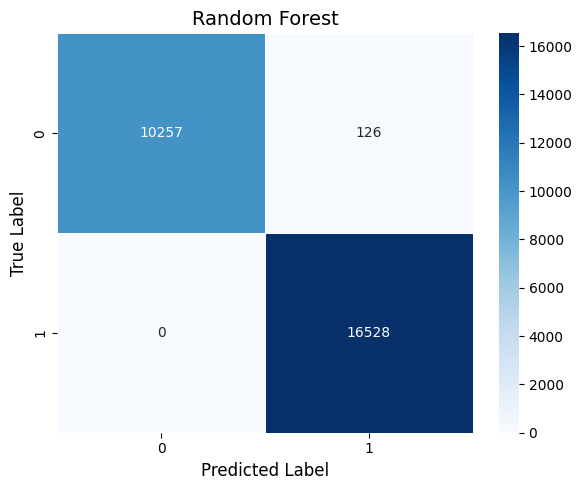

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 1. Initialize Random Forest (same hyperparameters)
# ======================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    min_impurity_decrease=0.01,
    bootstrap=True,
    random_state=42,
    class_weight='balanced'
)

# ======================================================
# 2. Train model (NO re-splitting)
# ======================================================

rf_model.fit(X_train, y_train)

# ======================================================
# 3. Predictions
# ======================================================

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf  = rf_model.predict(X_test)

# ======================================================
# 4. Evaluation
# ======================================================

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_rf):.6f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.6f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf))

# ======================================================
# 5. Confusion Matrix (same style as other models)
# ======================================================

conf_matrix = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    linewidths=0.5
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Random Forest', fontsize=14)
plt.tight_layout()
plt.show()


Random forest with 0, 7, 123 and 2024 seed value

In [34]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ------------------------------------------------------
# Data already prepared (FIXED – no re-splitting)
# X_train, X_test
# y_train, y_test
# ------------------------------------------------------

seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training Random Forest with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Set seed (model randomness only)
    # -----------------------------
    np.random.seed(seed)

    # -----------------------------
    # Random Forest model (UNCHANGED)
    # -----------------------------
    rf_model = RandomForestClassifier(
        n_estimators=100,
        min_impurity_decrease=0.01,
        bootstrap=True,
        random_state=seed,
        class_weight='balanced'
    )

    # -----------------------------
    # Train
    # -----------------------------
    rf_model.fit(X_train, y_train)

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_pred = rf_model.predict(X_test)

    # -----------------------------
    # Metrics (same as other models)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Test Metrics")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_rf = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\n📊 Random Forest – Seed Stability Results")
print(df_rf)

print("\n📈 Summary Statistics")
print(df_rf.describe())



 Training Random Forest with seed = 0

Seed 0 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

 Training Random Forest with seed = 7

Seed 7 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

 Training Random Forest with seed = 123

Seed 123 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

 Training Random Forest with seed = 2024

Seed 2024 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

📊 Random Forest – Seed Stability Results
   Seed      Accuracy   Precision  Recall            F1
0     0  0.9953178997  0.99243425     1.0  0.9962027605
1     7  0.9953178997  0.99243425     1.0  0.9962027605
2   123  0.9953178997  0.99243425     1.0  0.9962027605
3  2024  0.9953178997  0.99243425     1.0  0.9962027605

📈 Summary Statistics
                  Seed      Accuracy   Precision  Recall            F1
count  

# **XGboost**

Training Accuracy: 0.995866
Test Accuracy: 0.995318

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10383
           1       0.99      1.00      1.00     16528

    accuracy                           1.00     26911
   macro avg       1.00      0.99      1.00     26911
weighted avg       1.00      1.00      1.00     26911



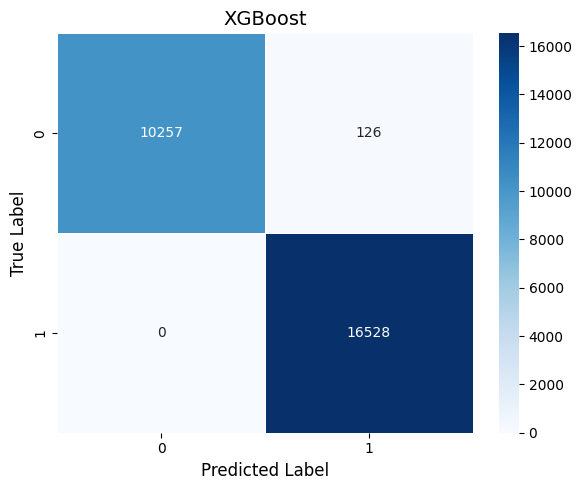

In [32]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# XGBoost Classifier (same settings)
# ======================================================

xgb_model = xgb.XGBClassifier(
    random_state=42,
    max_depth=3,
    learning_rate=0.01,
    objective='binary:logistic',
    eval_metric='logloss',   # avoids warnings
    use_label_encoder=False
)

# ======================================================
# Train model (NO re-splitting)
# ======================================================

xgb_model.fit(X_train, y_train)

# ======================================================
# Predictions
# ======================================================

y_train_pred_xgb = (xgb_model.predict(X_train) > 0.5).astype(int)
y_test_pred_xgb  = (xgb_model.predict(X_test) > 0.5).astype(int)

# ======================================================
# Evaluation
# ======================================================

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_xgb):.6f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_xgb):.6f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb))

# ======================================================
# Confusion Matrix (same style as other models)
# ======================================================

conf_matrix = confusion_matrix(y_test, y_test_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    linewidths=0.5
)

plt.title('XGBoost', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


XGBoost with 0, 7, 123 and 2024 seed value

In [36]:
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ------------------------------------------------------
# Data already prepared (FIXED – no re-splitting)
# X_train, X_test
# y_train, y_test
# ------------------------------------------------------

seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training XGBoost with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Set seed (model randomness only)
    # -----------------------------
    np.random.seed(seed)

    # -----------------------------
    # XGBoost model (UNCHANGED)
    # -----------------------------
    xgb_model = xgb.XGBClassifier(
        random_state=seed,
        max_depth=3,
        learning_rate=0.01,
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False
    )

    # -----------------------------
    # Train
    # -----------------------------
    xgb_model.fit(X_train, y_train)

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_pred = (xgb_model.predict(X_test) > 0.5).astype(int)

    # -----------------------------
    # Metrics (same as other models)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Test Metrics")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_xgb = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\n📊 XGBoost – Seed Stability Results")
print(df_xgb)

print("\n📈 Summary Statistics")
print(df_xgb.describe())



 Training XGBoost with seed = 0

Seed 0 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

 Training XGBoost with seed = 7

Seed 7 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

 Training XGBoost with seed = 123

Seed 123 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

 Training XGBoost with seed = 2024

Seed 2024 – Test Metrics
Accuracy : 0.995318
Precision: 0.992434
Recall   : 1.000000
F1-score : 0.996203

📊 XGBoost – Seed Stability Results
   Seed      Accuracy   Precision  Recall            F1
0     0  0.9953178997  0.99243425     1.0  0.9962027605
1     7  0.9953178997  0.99243425     1.0  0.9962027605
2   123  0.9953178997  0.99243425     1.0  0.9962027605
3  2024  0.9953178997  0.99243425     1.0  0.9962027605

📈 Summary Statistics
                  Seed      Accuracy   Precision  Recall            F1
count     4.0000000000  4.0000000000 

# **Logistic regression**

Training Accuracy: 0.908147
Test Accuracy: 0.908922

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     10383
           1       0.95      0.90      0.92     16528

    accuracy                           0.91     26911
   macro avg       0.90      0.91      0.91     26911
weighted avg       0.91      0.91      0.91     26911



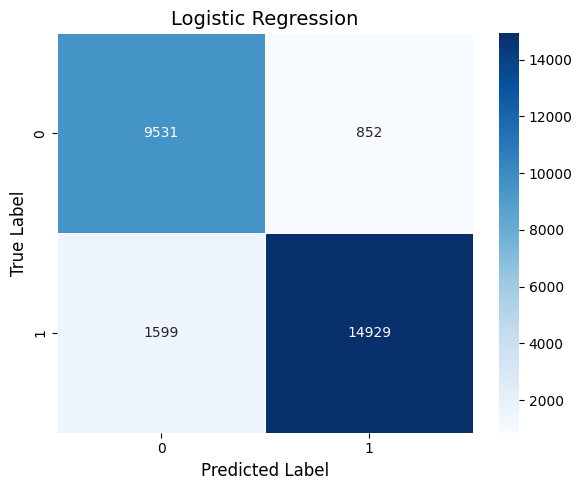

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# Logistic Regression (same robust configuration)
# =====================================================

logreg = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    random_state=42
)

# Train (NO scaled data, NO re-splitting)
logreg.fit(X_train, y_train)

# =====================================================
# Predictions
# =====================================================

y_train_pred_lr = logreg.predict(X_train)
y_test_pred_lr  = logreg.predict(X_test)

# =====================================================
# Evaluation
# =====================================================

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_lr):.6f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_lr):.6f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr))

# =====================================================
# Confusion Matrix (same style as other models)
# =====================================================

conf_matrix = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    linewidths=0.5
)

plt.title('Logistic Regression', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


Logistic Regression with 7 and 123 seed value

In [39]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ------------------------------------------------------
# Data already prepared (FIXED – no re-splitting)
# X_train, X_test
# y_train, y_test
# ------------------------------------------------------

seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training Logistic Regression with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Set seed (model randomness only)
    # -----------------------------
    np.random.seed(seed)

    # -----------------------------
    # Logistic Regression model (UNCHANGED)
    # -----------------------------
    logreg = LogisticRegression(
        max_iter=1000,
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        random_state=seed
    )

    # -----------------------------
    # Train
    # -----------------------------
    logreg.fit(X_train, y_train)

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_pred = logreg.predict(X_test)

    # -----------------------------
    # Metrics (same as other models)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Test Metrics")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_lr = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\n📊 Logistic Regression – Seed Stability Results")
print(df_lr)

print("\n📈 Summary Statistics")
print(df_lr.describe())



 Training Logistic Regression with seed = 0

Seed 0 – Test Metrics
Accuracy : 0.908848
Precision: 0.946004
Recall   : 0.903134
F1-score : 0.924072

 Training Logistic Regression with seed = 7

Seed 7 – Test Metrics
Accuracy : 0.908922
Precision: 0.946011
Recall   : 0.903255
F1-score : 0.924139

 Training Logistic Regression with seed = 123

Seed 123 – Test Metrics
Accuracy : 0.908922
Precision: 0.946011
Recall   : 0.903255
F1-score : 0.924139

 Training Logistic Regression with seed = 2024

Seed 2024 – Test Metrics
Accuracy : 0.908922
Precision: 0.946011
Recall   : 0.903255
F1-score : 0.924139

📊 Logistic Regression – Seed Stability Results
   Seed      Accuracy     Precision        Recall            F1
0     0  0.9088476831  0.9460041828  0.9031340755  0.9240721825
1     7  0.9089220022  0.9460110259  0.9032550823  0.9241387849
2   123  0.9089220022  0.9460110259  0.9032550823  0.9241387849
3  2024  0.9089220022  0.9460110259  0.9032550823  0.9241387849

📈 Summary Statistics
        

 **95% CI for top models using 0, 7, 42, 123 and 2024 seed value**

In [46]:
import numpy as np
import pandas as pd
from scipy.stats import t

def ci_summary_row(df, model_name):
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    n = len(df)
    t_val = t.ppf(0.975, df=n-1) if n > 1 else 0  # handles single-seed case

    row = {"Model": model_name}

    for m in metrics:
        mean = df[m].mean()
        sd   = df[m].std(ddof=1) if n > 1 else 0.0
        ci   = t_val * (sd / np.sqrt(n)) if n > 1 else 0.0

        row[f"{m}_Mean"] = mean
        row[f"{m}_SD"] = sd
        row[f"{m}_CI_Lower"] = mean - ci
        row[f"{m}_CI_Upper"] = mean + ci

    return row


In [47]:
ci_summary = pd.DataFrame([
    ci_summary_row(df_dt,    "Decision Tree"),
    ci_summary_row(df_lr,    "Logistic Regression"),
    ci_summary_row(df_xgb,   "XGBoost"),
    ci_summary_row(df_stack, "Stacking"),
    ci_summary_row(df_ffnn,  "Neural Network"),
    ci_summary_row(df_rf,  "Random forest"),
    ci_summary_row(df_cnn,  "CNN"),

])

pd.set_option("display.precision", 6)

print("\n================ 95% CI SUMMARY TABLE ================")
print(ci_summary)



================ 95% CI SUMMARY TABLE ================
                 Model  Accuracy_Mean  Accuracy_SD  Accuracy_CI_Lower  \
0        Decision Tree       0.994742     0.000021           0.994708   
1  Logistic Regression       0.908903     0.000037           0.908844   
2              XGBoost       0.995318     0.000000           0.995318   
3             Stacking       0.995169     0.000000           0.995169   
4       Neural Network       0.995318     0.000000           0.995318   
5        Random forest       0.995318     0.000000           0.995318   
6                  CNN       0.995225     0.000131           0.994045   

   Accuracy_CI_Upper  Precision_Mean  Precision_SD  Precision_CI_Lower  \
0           0.994776        0.992427  2.627735e-07            0.992427   
1           0.908963        0.946009  3.421571e-06            0.946004   
2           0.995318        0.992434  0.000000e+00            0.992434   
3           0.995169        0.992432  0.000000e+00            0

# **McNemar Tests**

In [34]:
# =================================================
# Generate & store TEST predictions for McNemar
# =================================================

# Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Logistic Regression
y_pred_lr = logreg.predict(X_test)

# Random Forest
y_pred_rf = rf_model.predict(X_test)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Stacking
y_pred_stack = stacking_classifier.predict(X_test)

# Feedforward Neural Network (FFNN)
y_pred_ffnn = (model.predict(X_test) >= 0.5).astype(int).ravel()

# CNN
y_pred_cnn = (model_cnn.predict(X_test_cnn) >= 0.5).astype(int).ravel()


841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
# =================================================
# Generate & store TEST predictions for McNemar
# =================================================

# Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Logistic Regression
y_pred_lr = logreg.predict(X_test)

# Random Forest
y_pred_rf = rf_model.predict(X_test)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Stacking
y_pred_stack = stacking_classifier.predict(X_test)

# Feedforward Neural Network (FFNN)
y_pred_ffnn = (model.predict(X_test) >= 0.5).astype(int).ravel()

# CNN
y_pred_cnn = (model_cnn.predict(X_test_cnn) >= 0.5).astype(int).ravel()


841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [36]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

# =================================================
# Test-set ground truth
# =================================================
y_true = y_test.values if hasattr(y_test, "values") else y_test

# =================================================
# Store TEST-SET predictions
# =================================================
predictions = {
    "Decision Tree": y_pred_dt,
    "Logistic Regression": y_pred_lr,
    "XGBoost": y_pred_xgb,
    "Stacking": y_pred_stack,
    "Feedforward NN": y_pred_ffnn,
    "CNN": y_pred_cnn
}

# =================================================
# McNemar test function (CHI-SQUARE ONLY)
# =================================================
def run_mcnemar(y_true, y_pred_a, y_pred_b):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred_a = pd.Series(y_pred_a).reset_index(drop=True)
    y_pred_b = pd.Series(y_pred_b).reset_index(drop=True)

    # Discordant pairs
    b = ((y_pred_a == y_true) & (y_pred_b != y_true)).sum()
    c = ((y_pred_a != y_true) & (y_pred_b == y_true)).sum()

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=False, correction=True)

    return b, c, result.statistic, result.pvalue

# =================================================
# Run McNemar tests (Stacking as reference)
# =================================================
reference_model = "Stacking"
results = []

for model_name, y_pred in predictions.items():
    if model_name == reference_model:
        continue

    b, c, chi2, p = run_mcnemar(
        y_true,
        predictions[reference_model],
        y_pred
    )

    results.append([
        reference_model,
        model_name,
        b,
        c,
        chi2,
        p
    ])

# =================================================
# Results table
# =================================================
df_mcnemar = pd.DataFrame(
    results,
    columns=[
        "Model_A",
        "Model_B",
        "A_correct_B_wrong (b)",
        "A_wrong_B_correct (c)",
        "Chi_square",
        "p_value"
    ]
)

pd.set_option("display.precision", 6)

print("\n================ McNemar Test Results ================")
print(df_mcnemar)



================ McNemar Test Results ================
    Model_A              Model_B  A_correct_B_wrong (b)  \
0  Stacking        Decision Tree                     14   
1  Stacking  Logistic Regression                   2359   
2  Stacking              XGBoost                      0   
3  Stacking       Feedforward NN                      0   
4  Stacking                  CNN                      4   

   A_wrong_B_correct (c)   Chi_square   p_value  
0                      3     5.882353  0.015293  
1                     38  2245.473509  0.000000  
2                      4     2.250000  0.133614  
3                      4     2.250000  0.133614  
4                      4     0.125000  0.723674  


# **Tabnet**

In [ ]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00



Early stopping occurred at epoch 28 with best_epoch = 18 and best_val_0_accuracy = 0.99522

✅ TabNet Test Metrics (Seed = 42)
Accuracy : 0.995244
Precision: 0.992374
Recall   : 0.999939
F1-score : 0.996142

📌 TabNet Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10383
           1       0.99      1.00      1.00     16528

    accuracy                           1.00     26911
   macro avg       1.00      0.99      0.99     26911
weighted avg       1.00      1.00      1.00     26911



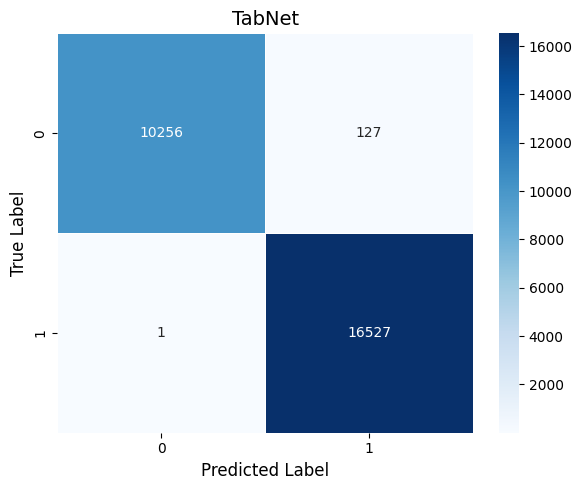

In [ ]:
# ======================================================
# TabNet – Single Seed (Seed = 42)
# ======================================================

import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------
# Convert to numpy float32 (TabNet requirement)
# ------------------------------------------------------
X_train_tab = X_train.values.astype(np.float32)
X_test_tab  = X_test.values.astype(np.float32)
y_train_tab = y_train.values.astype(np.int64)
y_test_tab  = y_test.values.astype(np.int64)

# ------------------------------------------------------
# Reproducibility
# ------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------
# INTERNAL validation split (TRAIN ONLY)
# ------------------------------------------------------
X_tr_tab, X_val_tab, y_tr_tab, y_val_tab = train_test_split(
    X_train_tab,
    y_train_tab,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_tab
)

# ------------------------------------------------------
# TabNet model (UNCHANGED hyperparameters)
# ------------------------------------------------------
tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    mask_type='entmax',
    seed=SEED,
    verbose=0
)

# ------------------------------------------------------
# Train (validation ONLY for early stopping)
# ------------------------------------------------------
tabnet.fit(
    X_tr_tab,
    y_tr_tab,
    eval_set=[(X_val_tab, y_val_tab)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

# ------------------------------------------------------
# FINAL evaluation on TEST set
# ------------------------------------------------------
y_test_pred = tabnet.predict(X_test_tab)

# ------------------------------------------------------
# Metrics
# ------------------------------------------------------
acc  = accuracy_score(y_test_tab, y_test_pred)
prec = precision_score(y_test_tab, y_test_pred, zero_division=0)
rec  = recall_score(y_test_tab, y_test_pred, zero_division=0)
f1   = f1_score(y_test_tab, y_test_pred, zero_division=0)

print("\n✅ TabNet Test Metrics (Seed = 42)")
print(f"Accuracy : {acc:.6f}")
print(f"Precision: {prec:.6f}")
print(f"Recall   : {rec:.6f}")
print(f"F1-score : {f1:.6f}")

# ------------------------------------------------------
# Classification Report (TEST SET)
# ------------------------------------------------------
print("\n📌 TabNet Classification Report (Test Set):")
print(classification_report(y_test_tab, y_test_pred))

# ------------------------------------------------------
# Confusion Matrix (same style as previous models)
# ------------------------------------------------------
cm_tab = confusion_matrix(y_test_tab, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tab,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    linewidths=0.5
)

plt.title("TabNet", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()
